In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve)
from sklearn.pipeline import Pipeline

In [67]:
df = pd.read_csv('train_data.csv')

print("Размер датасета:", df.shape)
print("Распределение классов:\n", df['Survived'].value_counts(normalize=True))

Размер датасета: (792, 17)
Распределение классов:
 Survived
0    0.613636
1    0.386364
Name: proportion, dtype: float64


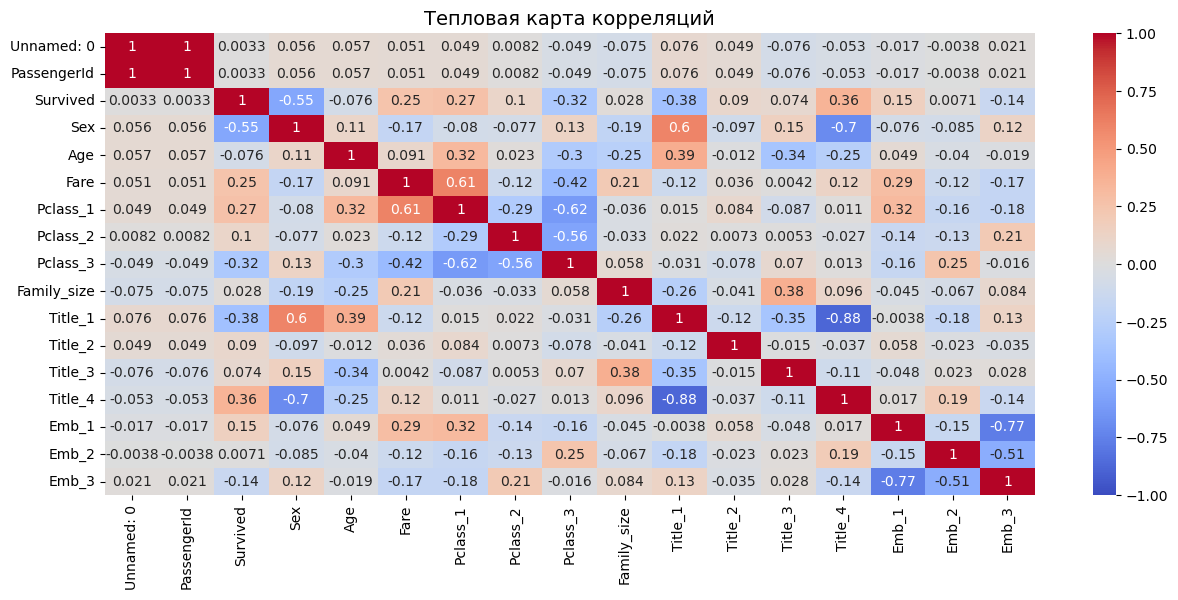

In [68]:
corr_matrix = df.corr()
plt.figure(figsize=(15, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Тепловая карта корреляций', fontsize=14)
plt.show()

In [69]:
df['PClass_code'] = df[['Pclass_1','Pclass_2','Pclass_3']].idxmax(axis=1).str[-1].astype(int)
df['Title_code'] = df[['Title_1','Title_2','Title_3','Title_4']].idxmax(axis=1).str[-1].astype(int)
df['Emb_code'] = df[['Emb_1','Emb_2','Emb_3']].idxmax(axis=1).str[-1].astype(int)

X = df.drop(['Survived', 'Title_1', 'Title_2', 'Title_3', 'Title_4', 'Emb_1', 'Emb_2', 'Emb_3', 'Pclass_1', 'Pclass_2', 'Pclass_3'], axis=1)
y = df['Survived']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 554, Val: 119, Test: 119


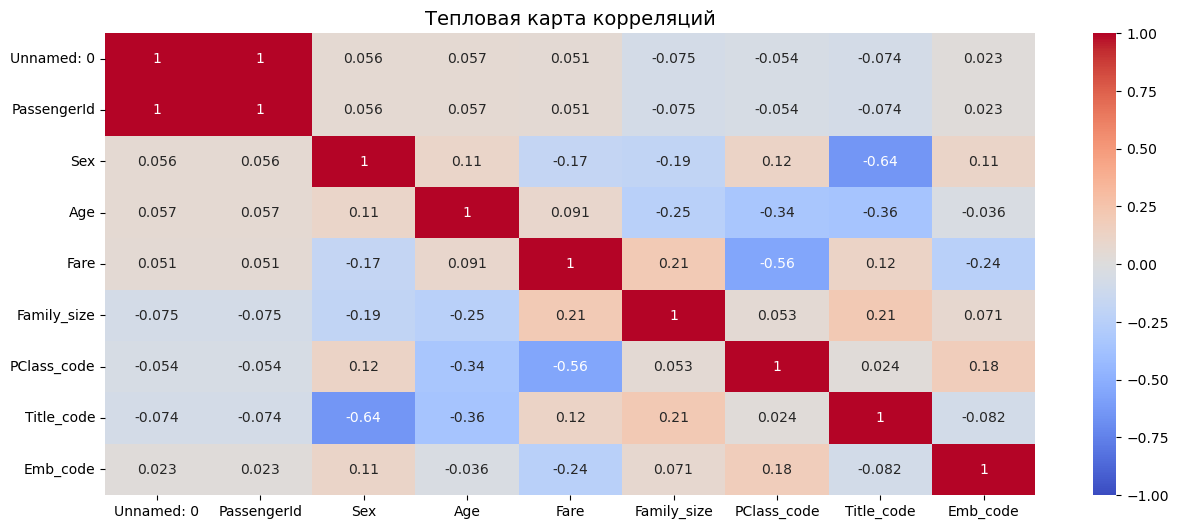

In [70]:
corr_matrix = X.corr()
plt.figure(figsize=(15, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Тепловая карта корреляций', fontsize=14)
plt.show()

In [71]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(random_state=0, max_iter=1000, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [72]:
y_val_pred = clf.predict(X_val_scaled)
print("Метрики на валидации")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-score:  {f1_score(y_val, y_val_pred):.4f}")

Метрики на валидации
Precision: 0.6731
Recall:    0.7609
F1-score:  0.7143


In [73]:
probs_val = clf.predict_proba(X_val_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, probs_val)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"Оптимальный порог: {best_threshold:.5f}")

y_val_pred_adj = (probs_val >= best_threshold).astype(int)
print("\nМетрики на валидации (оптимальный порог)")
print(f"Precision: {precision_score(y_val, y_val_pred_adj):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_adj):.4f}")
print(f"F1-score:  {f1_score(y_val, y_val_pred_adj):.4f}")

Оптимальный порог: 0.48985

Метрики на валидации (оптимальный порог)
Precision: 0.6792
Recall:    0.7826
F1-score:  0.7273


In [74]:
y_test_probs = clf.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("Финальные метрики")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_pred):.4f}")

Финальные метрики
Precision: 0.6786
Recall:    0.8261
F1-score:  0.7451


In [75]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [76]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(path + "/creditcard.csv", encoding='latin-1')

print("Размер датасета:", df.shape)
print("Распределение классов:\n", df['Class'].value_counts(normalize=True))

Размер датасета: (284807, 31)
Распределение классов:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [77]:
X = df.drop("Class", axis=1)
y = df['Class']

In [78]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 199364, Val: 42721, Test: 42722


In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [80]:
clf = LogisticRegression(random_state=0, max_iter=1000, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [81]:
y_val_pred = clf.predict(X_val_scaled)
print("Метрики на валидации")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-score:  {f1_score(y_val, y_val_pred):.4f}")

Метрики на валидации
Precision: 0.0671
Recall:    0.8784
F1-score:  0.1246


In [82]:
probs_val = clf.predict_proba(X_val_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, probs_val)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"Оптимальный порог: {best_threshold:.5f}")

y_val_pred_adj = (probs_val >= best_threshold).astype(int)
print("\nМетрики на валидации (оптимальный порог)")
print(f"Precision: {precision_score(y_val, y_val_pred_adj):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_adj):.4f}")
print(f"F1-score:  {f1_score(y_val, y_val_pred_adj):.4f}")

Оптимальный порог: 1.00000

Метрики на валидации (оптимальный порог)
Precision: 0.8000
Recall:    0.7568
F1-score:  0.7778


In [83]:
y_test_probs = clf.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("Финальные метрики")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_pred):.4f}")

Финальные метрики
Precision: 0.9062
Recall:    0.7838
F1-score:  0.8406


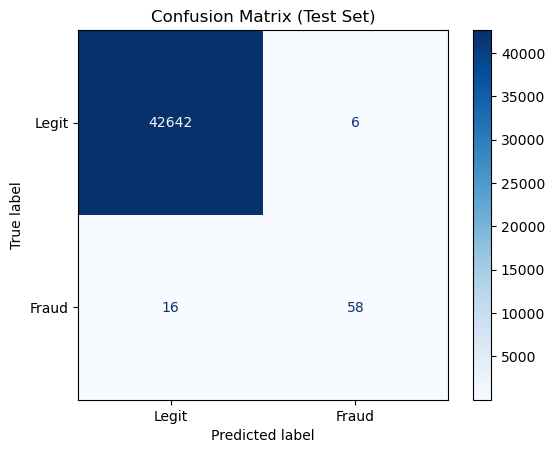

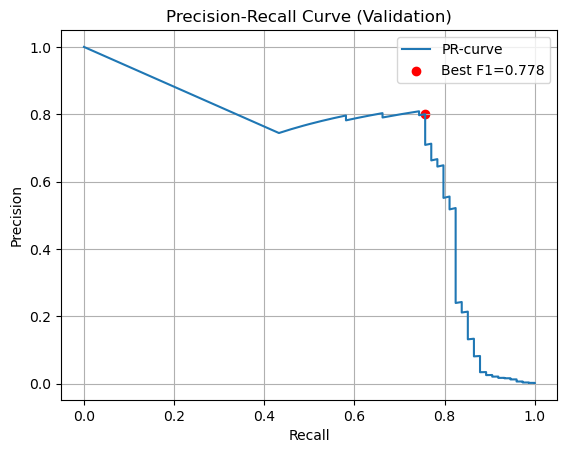

In [84]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test Set)")
plt.show()

plt.figure()
plt.plot(recalls, precisions, label='PR-curve')
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', label=f'Best F1={f1_scores[best_idx]:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Validation)')
plt.legend()
plt.grid(True)
plt.show()